# TikTok Algorithm Analysis - Indifferent Dataset
## Analýza personalizace feedu pro uživatele bez stance preference
---

**Charakteristika datasetu:**
- Všichni uživatelé mají stance = "indifferent"
- Uživatelé lajkují videa pouze pokud matchuje topic
- Není zde rozlišení support/oppose stance videí
- Žádný neutral topic (recipes)

# 1. KNIHOVNY A KONFIGURACE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

# Vytvoření output složky
os.makedirs("output", exist_ok=True)

# Barevná paleta
COLORS = {
    'topic_match': '#2ecc71',    # zelená - topic match (lajknuté)
    'random': '#95a5a6',          # šedá - random (nelajknuté)
    'skip': '#e74c3c',            # červená
    'watch': '#3498db',           # modrá
    'like': '#f39c12',            # oranžová
    'bookmark': '#9b59b6'         # fialová
}

# Nastavení grafů
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("✓ Knihovny načteny")

✓ Knihovny načteny


# 2. NAČTENÍ DAT

In [2]:
# ============================================
# UPRAV CESTU K SOUBORU
# ============================================
DATA_PATH = r"C:\Users\Michal Tvaroh\PycharmProjects\Jupyter3\data\data_indifferent.csv"

df = pd.read_csv(DATA_PATH)
print(f"✓ Data načtena: {len(df):,} záznamů")
print(f"  Sloupce: {len(df.columns)}")
display(df.head(3))

✓ Data načtena: 10,587 záznamů
  Sloupce: 29


,interaction_number,search_term,video_url,video_id,video_author,video_description,video_time_duration,video_transcript,video_transcript_language,video_action_skip,...,user_email,topic,stance,gender,country_code,date_of_birth,run_id,predicted_topic_match,predicted_topic,predicted_stance_match
0,1,NaN,https://www.tiktok.com/@00rie00/video/75733976...,7573397624322084103,00rie00,يمه يشبه ابوي 🫢🫢 #aiuniverse #explore #فوريو_ا...,8.120000,NaN,NaN,True,...,user2026+bertha.giess@zohomail.eu,beauty,indifferent,female,DE,2009-11-29,1765366608.8919947_main,False,random,False
1,2,NaN,https://www.tiktok.com/@itsbabykelz/video/7581...,7581205822701587767,itsbabykelz,imma need you guys to lock in! 👀 this is the s...,151.439002,NaN,NaN,False,...,user2026+bertha.giess@zohomail.eu,beauty,indifferent,female,DE,2009-11-29,1765366608.8919947_main,True,beauty,False
2,3,NaN,https://www.tiktok.com/@bedside_convo/video/75...,7574727393605094669,bedside_convo,no sponsorships cuz literally no brand can pay...,142.934000,NaN,NaN,False,...,user2026+bertha.giess@zohomail.eu,beauty,indifferent,female,DE,2009-11-29,1765366608.8919947_main,True,beauty,False


# 3. PŘÍPRAVA DAT

In [3]:
# Identifikátory
df['session_id'] = df['run_id']
df['user_id'] = df['user_email'] + ' | ' + df['topic']

# Kategorie videí (zjednodušené - jen topic match nebo random)
df['video_category'] = np.where(df['predicted_topic_match'], 'Topic Match', 'Random')

# Dynamické získání všech topics
ALL_TOPICS = sorted(df['topic'].unique().tolist())

# Seznam uživatelů
users = df['user_id'].unique().tolist()

print(f"✓ Data připravena")
print(f"  Unikátních uživatelů: {df['user_email'].nunique()}")
print(f"  Unikátních sessions: {df['run_id'].nunique()}")
print(f"  Topics ({len(ALL_TOPICS)}): {ALL_TOPICS}")

✓ Data připravena
  Unikátních uživatelů: 8
  Unikátních sessions: 70
  Topics (4): ['beauty', 'fitness', 'gaming', 'politics']


---
# 4. GLOBÁLNÍ PŘEHLED
---

## 4.1 Distribuce Topic Match vs Random

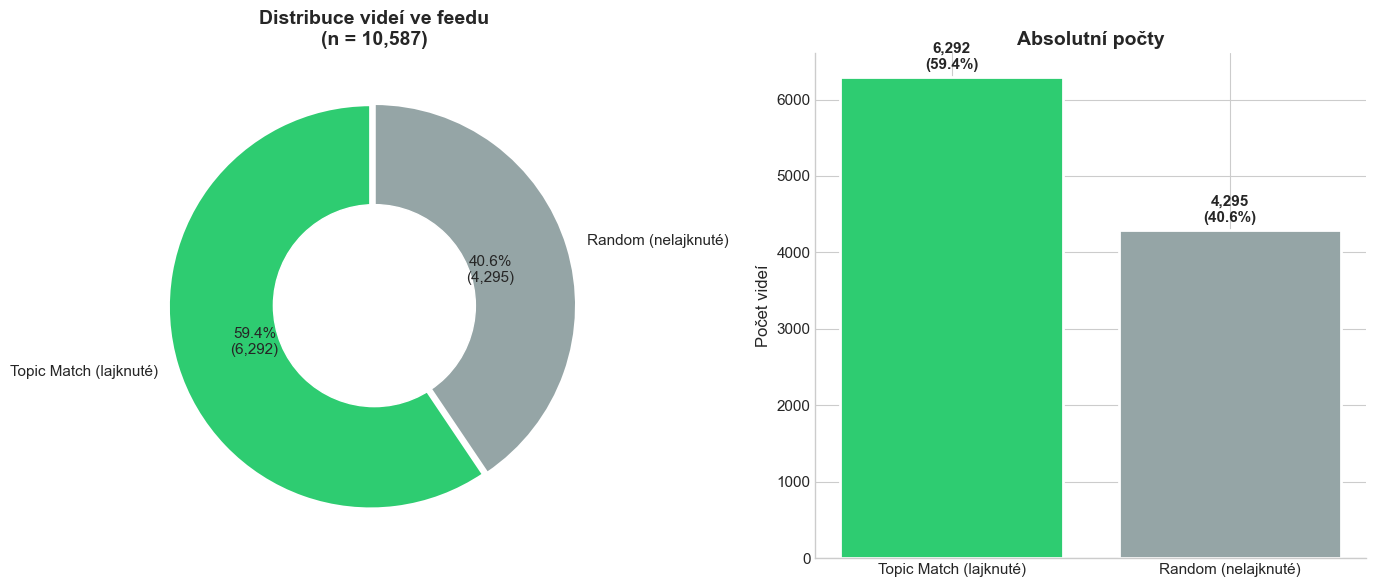


📊 Topic Match Rate: 59.43%


In [4]:
total = len(df)
topic_match_count = df['predicted_topic_match'].sum()
random_count = total - topic_match_count

categories = {
    'Topic Match (lajknuté)': topic_match_count,
    'Random (nelajknuté)': random_count
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut chart
colors = [COLORS['topic_match'], COLORS['random']]
wedges, texts, autotexts = axes[0].pie(
    categories.values(), 
    labels=categories.keys(),
    autopct=lambda p: f'{p:.1f}%\n({int(p*total/100):,})',
    colors=colors,
    startangle=90,
    explode=(0.02, 0),
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
axes[0].add_patch(centre_circle)
axes[0].set_title(f'Distribuce videí ve feedu\n(n = {total:,})', fontweight='bold')

# Bar chart
bars = axes[1].bar(categories.keys(), categories.values(), color=colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, categories.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + total*0.01, 
                 f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_ylabel('Počet videí')
axes[1].set_title('Absolutní počty', fontweight='bold')

plt.tight_layout()
plt.savefig('output/01_global_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Topic Match Rate: {topic_match_count/total*100:.2f}%")

## 4.2 Distribuce podle Topic

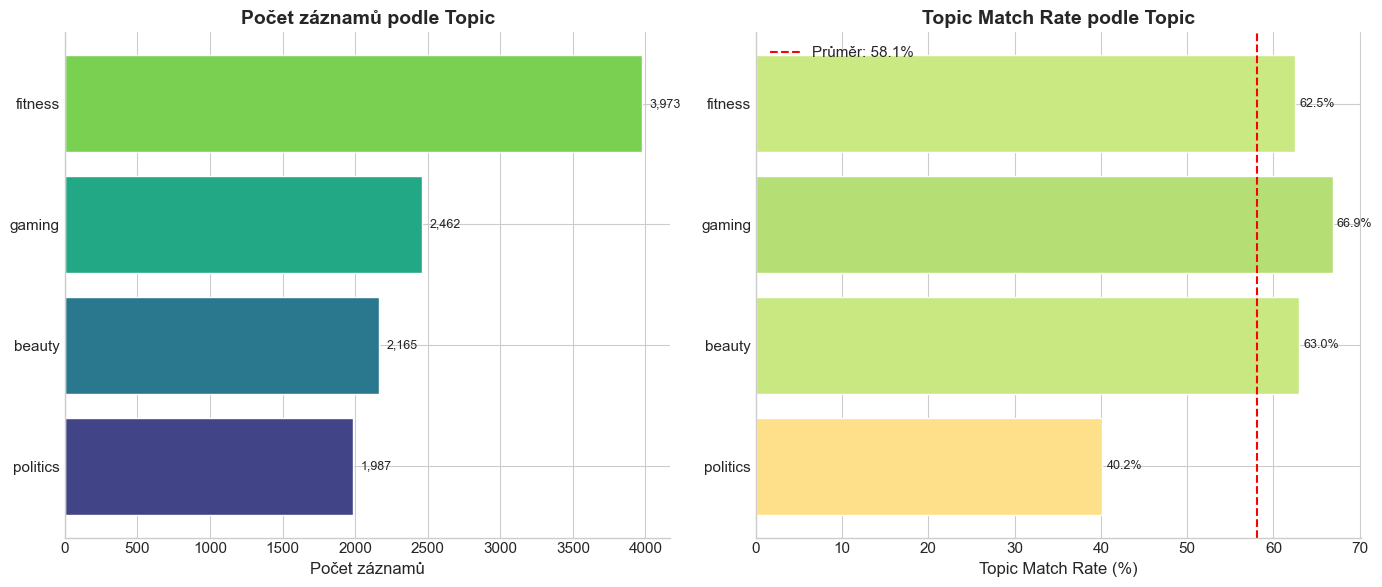

In [5]:
# Počet záznamů a topic match rate podle topic
topic_stats = df.groupby('topic').agg(
    count=('interaction_number', 'count'),
    topic_match_rate=('predicted_topic_match', 'mean'),
    like_rate=('video_action_like', 'mean'),
    watch_rate=('video_action_watch', 'mean'),
    skip_rate=('video_action_skip', 'mean')
).sort_values('count', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(ALL_TOPICS) * 0.5)))

# Počet záznamů
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(topic_stats)))
bars = axes[0].barh(topic_stats.index, topic_stats['count'], color=colors_bar, edgecolor='white')
for bar, val in zip(bars, topic_stats['count']):
    axes[0].text(val + total*0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_xlabel('Počet záznamů')
axes[0].set_title('Počet záznamů podle Topic', fontweight='bold')

# Topic match rate
colors_rate = plt.cm.RdYlGn(topic_stats['topic_match_rate'])
bars = axes[1].barh(topic_stats.index, topic_stats['topic_match_rate'] * 100, color=colors_rate, edgecolor='white')
for bar, val in zip(bars, topic_stats['topic_match_rate'] * 100):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_xlabel('Topic Match Rate (%)')
axes[1].set_title('Topic Match Rate podle Topic', fontweight='bold')
axes[1].axvline(x=topic_stats['topic_match_rate'].mean()*100, color='red', linestyle='--', 
                label=f'Průměr: {topic_stats["topic_match_rate"].mean()*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/02_topic_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 5. ANALÝZA INTERAKCÍ
---

## 5.1 Celkové interakce

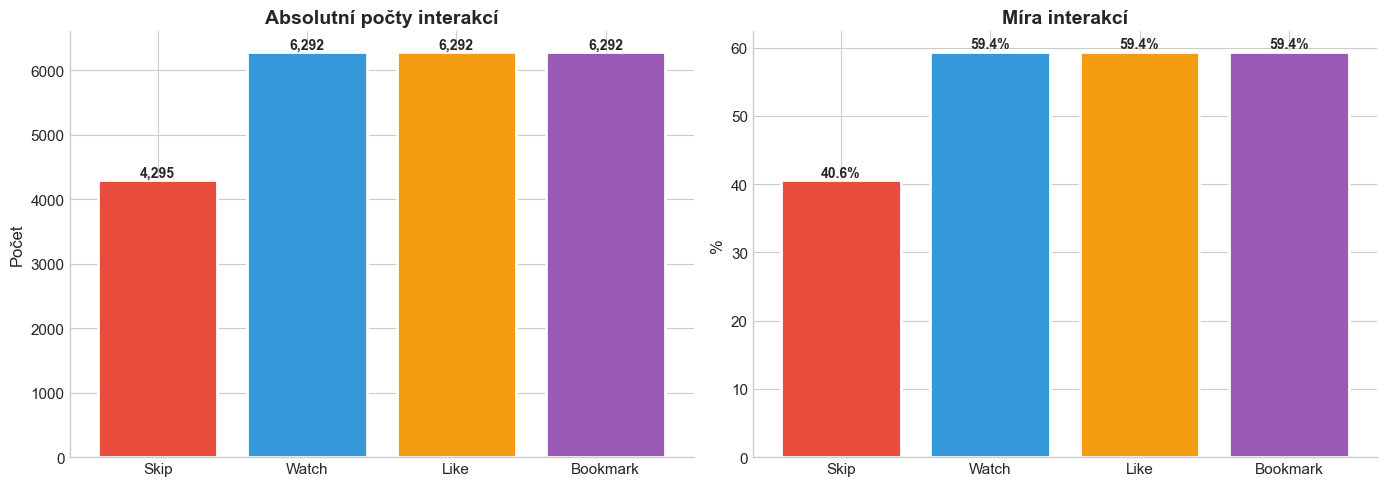

In [6]:
# Celkové statistiky interakcí
interactions = {
    'Skip': df['video_action_skip'].sum(),
    'Watch': df['video_action_watch'].sum(),
    'Like': df['video_action_like'].sum(),
    'Bookmark': df['video_action_bookmark'].sum()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolutní počty
colors_int = [COLORS['skip'], COLORS['watch'], COLORS['like'], COLORS['bookmark']]
bars = axes[0].bar(interactions.keys(), interactions.values(), color=colors_int, edgecolor='white', linewidth=2)
for bar, val in zip(bars, interactions.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + total*0.005, 
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Počet')
axes[0].set_title('Absolutní počty interakcí', fontweight='bold')

# Procentuální
rates = {k: v/total*100 for k, v in interactions.items()}
bars = axes[1].bar(rates.keys(), rates.values(), color=colors_int, edgecolor='white', linewidth=2)
for bar, val in zip(bars, rates.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5, 
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('%')
axes[1].set_title('Míra interakcí', fontweight='bold')

plt.tight_layout()
plt.savefig('output/03_interactions_overview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5.2 Interakce: Topic Match vs Random

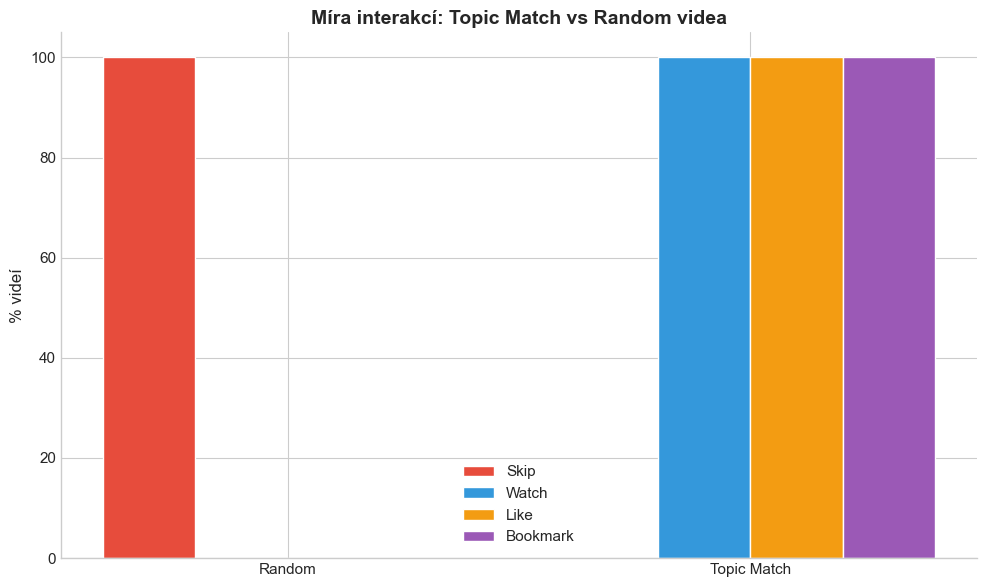


📊 Detailní srovnání:


,video_action_skip,video_action_watch,video_action_like,video_action_bookmark
video_category,,,,
Random,100.0,0.0,0.0,0.0
Topic Match,0.0,100.0,100.0,100.0


In [7]:
# Srovnání interakcí pro topic match vs random videa
interaction_comparison = df.groupby('video_category').agg({
    'video_action_skip': 'mean',
    'video_action_watch': 'mean',
    'video_action_like': 'mean',
    'video_action_bookmark': 'mean'
}) * 100

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(interaction_comparison.index))
width = 0.2

ax.bar(x - 1.5*width, interaction_comparison['video_action_skip'], width, label='Skip', color=COLORS['skip'])
ax.bar(x - 0.5*width, interaction_comparison['video_action_watch'], width, label='Watch', color=COLORS['watch'])
ax.bar(x + 0.5*width, interaction_comparison['video_action_like'], width, label='Like', color=COLORS['like'])
ax.bar(x + 1.5*width, interaction_comparison['video_action_bookmark'], width, label='Bookmark', color=COLORS['bookmark'])

ax.set_xticks(x)
ax.set_xticklabels(interaction_comparison.index)
ax.set_ylabel('% videí')
ax.set_title('Míra interakcí: Topic Match vs Random videa', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('output/04_interactions_by_category.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Detailní srovnání:")
display(interaction_comparison.round(2))

## 5.3 Engagement Funnel

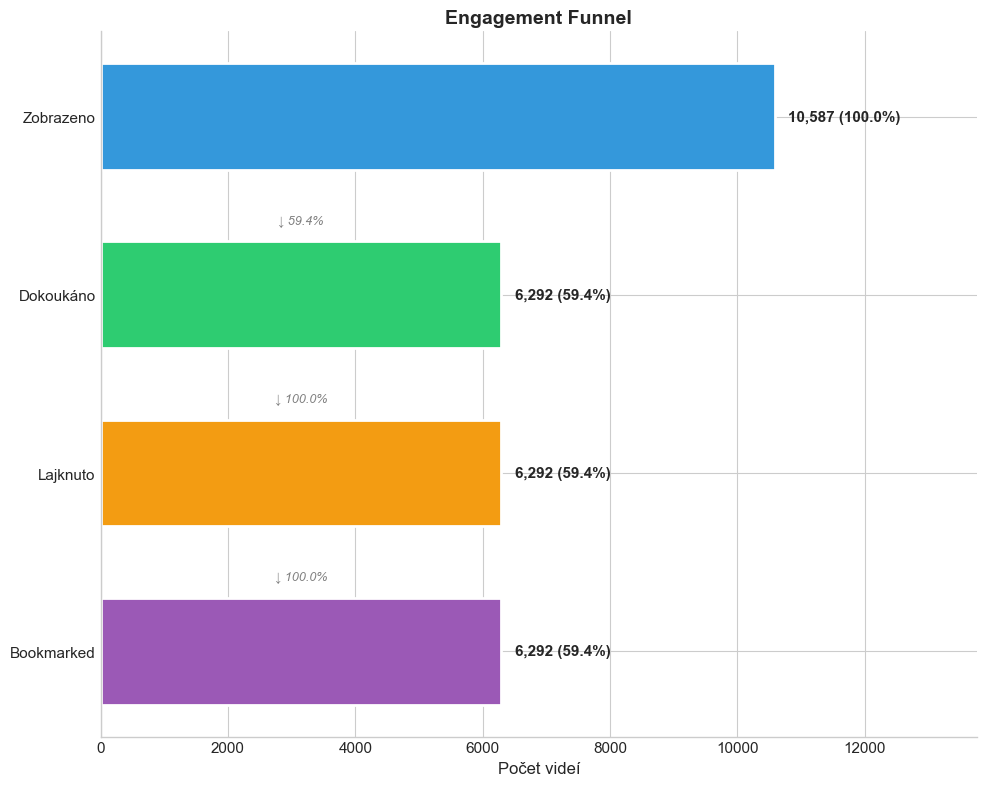

In [8]:
# Funnel: Zobrazeno → Watch → Like → Bookmark
funnel = {
    'Zobrazeno': total,
    'Dokoukáno': df['video_action_watch'].sum(),
    'Lajknuto': df['video_action_like'].sum(),
    'Bookmarked': df['video_action_bookmark'].sum()
}

fig, ax = plt.subplots(figsize=(10, 8))

stages = list(funnel.keys())
values = list(funnel.values())
y_pos = range(len(stages)-1, -1, -1)

colors_funnel = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax.barh(y_pos, values, color=colors_funnel, edgecolor='white', linewidth=2, height=0.6)

for i, (bar, val) in enumerate(zip(bars, values)):
    pct = val/total*100
    ax.text(val + total*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

# Konverzní rate
for i in range(len(values)-1):
    if values[i] > 0:
        conv = values[i+1] / values[i] * 100
        ax.annotate(f'↓ {conv:.1f}%', xy=(min(values[i], values[i+1])/2, y_pos[i+1]+0.4),
                    fontsize=9, color='gray', style='italic', ha='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(stages)
ax.set_xlabel('Počet videí')
ax.set_title('Engagement Funnel', fontweight='bold')
ax.set_xlim(0, total * 1.3)

plt.tight_layout()
plt.savefig('output/05_engagement_funnel.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5.4 Heatmapa: Interakce × Topic

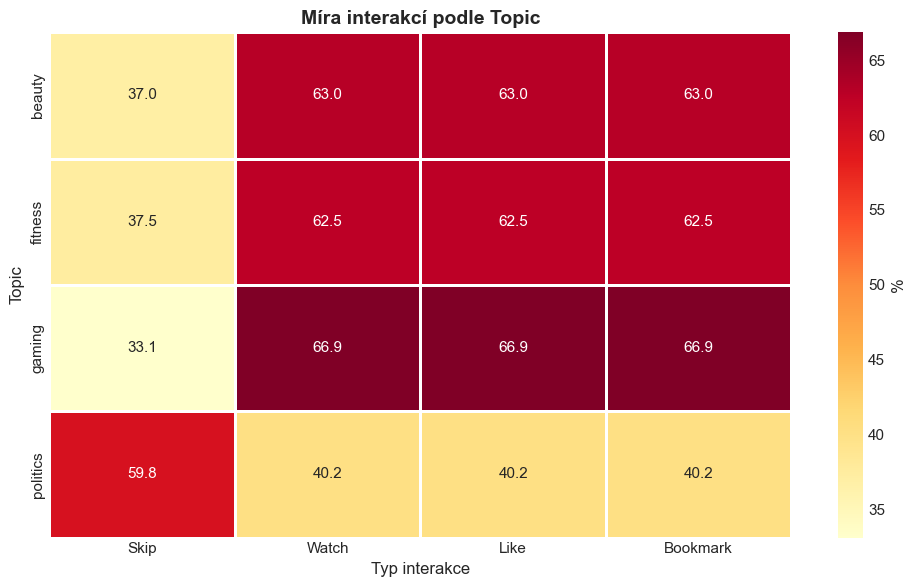

In [9]:
# Heatmapa interakcí podle topic
heatmap_data = df.groupby('topic').agg({
    'video_action_skip': 'mean',
    'video_action_watch': 'mean',
    'video_action_like': 'mean',
    'video_action_bookmark': 'mean'
}) * 100

heatmap_data.columns = ['Skip', 'Watch', 'Like', 'Bookmark']

fig, ax = plt.subplots(figsize=(10, max(6, len(ALL_TOPICS) * 0.4)))

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=1, linecolor='white', cbar_kws={'label': '%'})
ax.set_title('Míra interakcí podle Topic', fontweight='bold')
ax.set_xlabel('Typ interakce')
ax.set_ylabel('Topic')

plt.tight_layout()
plt.savefig('output/06_interaction_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 6. VÝVOJ V ČASE (SLIDING WINDOW)
---

## 6.1 Topic Match Rate v průběhu session

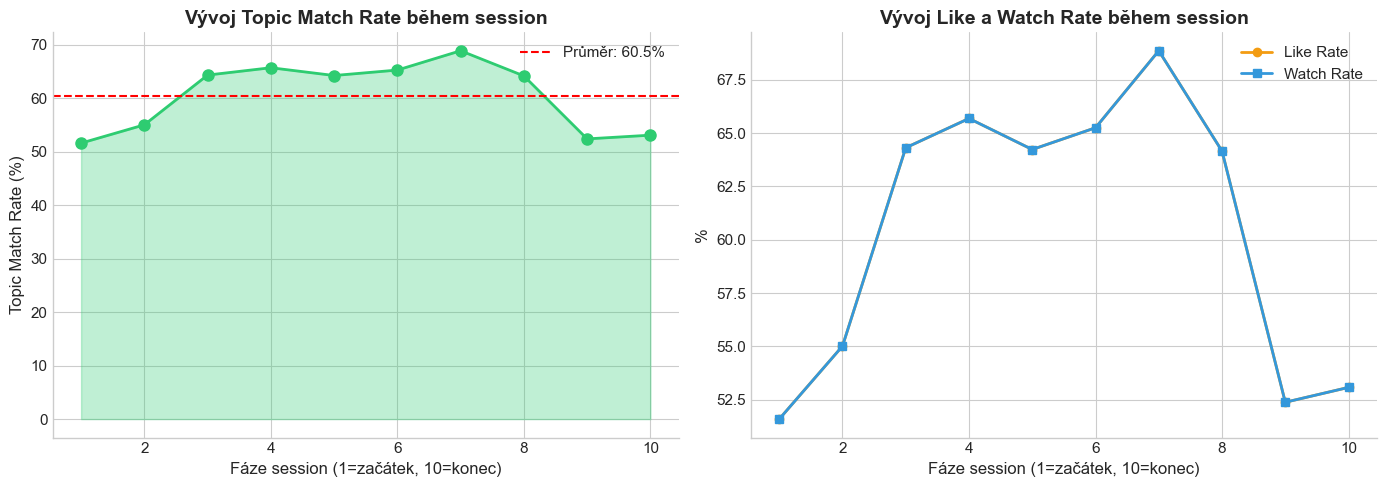

In [10]:
WINDOW = 50

# Celkový vývoj
df_sorted = df.sort_values(['user_id', 'interaction_number']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binování do fází session
df['interaction_bin'] = pd.cut(df['interaction_number'], bins=10, labels=False) + 1

# Topic match progress
progress = df.groupby('interaction_bin')['predicted_topic_match'].mean() * 100

axes[0].plot(progress.index, progress.values, marker='o', linewidth=2, markersize=8, color=COLORS['topic_match'])
axes[0].fill_between(progress.index, progress.values, alpha=0.3, color=COLORS['topic_match'])
axes[0].set_xlabel('Fáze session (1=začátek, 10=konec)')
axes[0].set_ylabel('Topic Match Rate (%)')
axes[0].set_title('Vývoj Topic Match Rate během session', fontweight='bold')
axes[0].axhline(y=progress.mean(), color='red', linestyle='--', label=f'Průměr: {progress.mean():.1f}%')
axes[0].legend()

# Like rate progress
like_progress = df.groupby('interaction_bin')['video_action_like'].mean() * 100
watch_progress = df.groupby('interaction_bin')['video_action_watch'].mean() * 100

axes[1].plot(like_progress.index, like_progress.values, marker='o', linewidth=2, label='Like Rate', color=COLORS['like'])
axes[1].plot(watch_progress.index, watch_progress.values, marker='s', linewidth=2, label='Watch Rate', color=COLORS['watch'])
axes[1].set_xlabel('Fáze session (1=začátek, 10=konec)')
axes[1].set_ylabel('%')
axes[1].set_title('Vývoj Like a Watch Rate během session', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/07_session_progress.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6.2 Sliding Window podle Topic

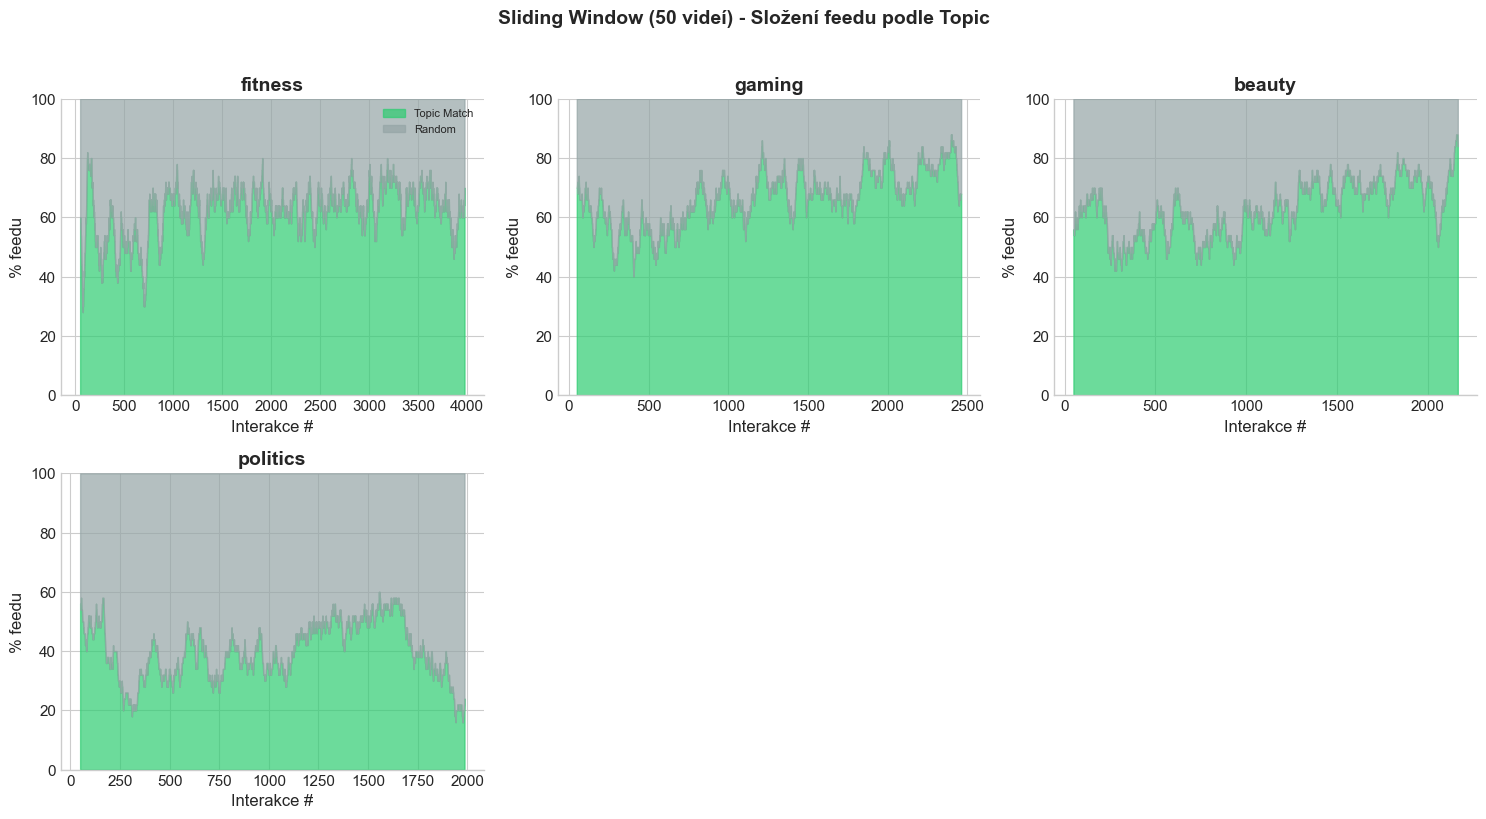

In [11]:
# Vyber max 6 topics pro vizualizaci
top_topics = df['topic'].value_counts().head(6).index.tolist()
n_topics = len(top_topics)

n_cols = min(3, n_topics)
n_rows = (n_topics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_topics > 1 else [axes]

for idx, topic in enumerate(top_topics):
    ax = axes[idx]
    topic_df = df[df['topic'] == topic].sort_values('interaction_number').reset_index(drop=True)
    
    if len(topic_df) < WINDOW:
        ax.set_title(f"{topic}\n(nedostatek dat)")
        continue
    
    rolling_match = topic_df['predicted_topic_match'].rolling(WINDOW).mean() * 100
    rolling_random = (~topic_df['predicted_topic_match']).rolling(WINDOW).mean() * 100
    
    ax.fill_between(range(len(rolling_match)), 0, rolling_match, alpha=0.7, 
                    label='Topic Match', color=COLORS['topic_match'])
    ax.fill_between(range(len(rolling_match)), rolling_match, 100, alpha=0.7,
                    label='Random', color=COLORS['random'])
    
    ax.set_title(f"{topic}", fontweight='bold')
    ax.set_xlabel('Interakce #')
    ax.set_ylabel('% feedu')
    ax.set_ylim(0, 100)
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

# Skryj prázdné subplots
for idx in range(n_topics, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Sliding Window ({WINDOW} videí) - Složení feedu podle Topic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/08_sliding_window_topics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
# 7. ANALÝZA DÉLKY VIDEÍ
---

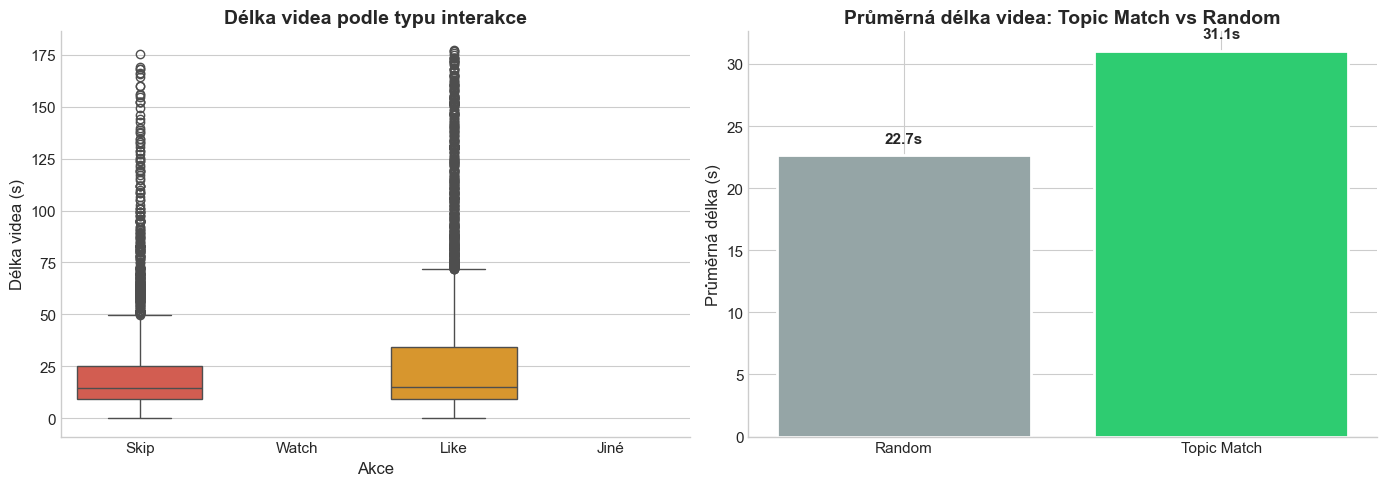

In [12]:
# Analýza délky videí
if 'video_time_duration' in df.columns:
    # Filtrovat extrémní hodnoty
    df_duration = df[df['video_time_duration'] < df['video_time_duration'].quantile(0.95)].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot podle akce
    df_duration['primary_action'] = 'Jiné'
    df_duration.loc[df_duration['video_action_skip'] == True, 'primary_action'] = 'Skip'
    df_duration.loc[df_duration['video_action_watch'] == True, 'primary_action'] = 'Watch'
    df_duration.loc[df_duration['video_action_like'] == True, 'primary_action'] = 'Like'
    
    order = ['Skip', 'Watch', 'Like', 'Jiné']
    colors_box = [COLORS['skip'], COLORS['watch'], COLORS['like'], '#95a5a6']
    
    sns.boxplot(data=df_duration, x='primary_action', y='video_time_duration', 
                order=order, palette=colors_box, ax=axes[0])
    axes[0].set_xlabel('Akce')
    axes[0].set_ylabel('Délka videa (s)')
    axes[0].set_title('Délka videa podle typu interakce', fontweight='bold')
    
    # Průměrná délka podle topic match
    avg_duration = df_duration.groupby('video_category')['video_time_duration'].mean()
    bars = axes[1].bar(avg_duration.index, avg_duration.values, 
                       color=[COLORS['random'], COLORS['topic_match']], edgecolor='white', linewidth=2)
    for bar, val in zip(bars, avg_duration.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}s', 
                     ha='center', fontweight='bold')
    axes[1].set_ylabel('Průměrná délka (s)')
    axes[1].set_title('Průměrná délka videa: Topic Match vs Random', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('output/09_video_duration.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Sloupec video_time_duration není k dispozici")

---
# 8. DEMOGRAFICKÁ ANALÝZA
---

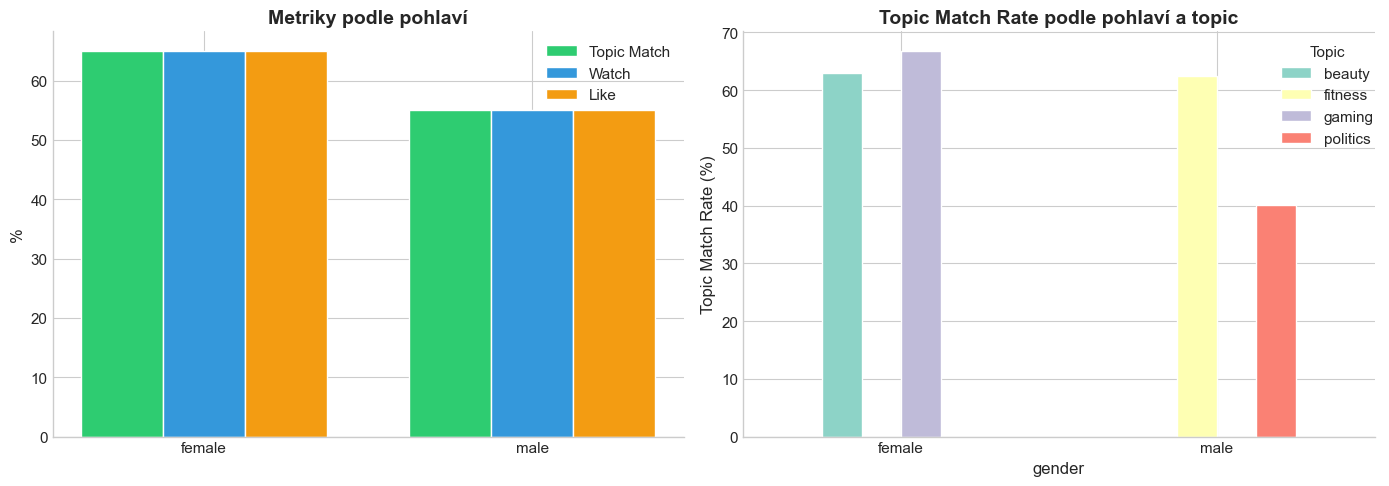

In [13]:
# Analýza podle pohlaví (pokud existuje)
if 'gender' in df.columns and df['gender'].nunique() > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Topic match rate podle pohlaví
    gender_stats = df.groupby('gender').agg({
        'predicted_topic_match': 'mean',
        'video_action_watch': 'mean',
        'video_action_like': 'mean'
    }) * 100
    
    x = np.arange(len(gender_stats.index))
    width = 0.25
    
    axes[0].bar(x - width, gender_stats['predicted_topic_match'], width, label='Topic Match', color=COLORS['topic_match'])
    axes[0].bar(x, gender_stats['video_action_watch'], width, label='Watch', color=COLORS['watch'])
    axes[0].bar(x + width, gender_stats['video_action_like'], width, label='Like', color=COLORS['like'])
    
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(gender_stats.index)
    axes[0].set_ylabel('%')
    axes[0].set_title('Metriky podle pohlaví', fontweight='bold')
    axes[0].legend()
    
    # Topic match rate podle pohlaví a topic
    gender_topic = df.groupby(['gender', 'topic'])['predicted_topic_match'].mean().unstack() * 100
    gender_topic.plot(kind='bar', ax=axes[1], edgecolor='white', linewidth=1)
    axes[1].set_ylabel('Topic Match Rate (%)')
    axes[1].set_title('Topic Match Rate podle pohlaví a topic', fontweight='bold')
    axes[1].legend(title='Topic', bbox_to_anchor=(1.02, 1))
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.savefig('output/10_gender_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Demografická analýza podle pohlaví není k dispozici (jeden nebo žádný gender)")

---
# 9. SOUHRN
---

In [14]:
# Souhrnná tabulka podle topic
summary = df.groupby('topic').agg(
    Videos=('interaction_number', 'count'),
    Users=('user_email', 'nunique'),
    Sessions=('run_id', 'nunique'),
    Topic_Match_Rate=('predicted_topic_match', 'mean'),
    Watch_Rate=('video_action_watch', 'mean'),
    Like_Rate=('video_action_like', 'mean'),
    Skip_Rate=('video_action_skip', 'mean'),
    Bookmark_Rate=('video_action_bookmark', 'mean')
).round(4)

# Formátování procent
for col in ['Topic_Match_Rate', 'Watch_Rate', 'Like_Rate', 'Skip_Rate', 'Bookmark_Rate']:
    summary[col] = (summary[col] * 100).round(1).astype(str) + '%'

print("=" * 100)
print("SOUHRNNÉ STATISTIKY PODLE TOPIC")
print("=" * 100)
display(summary)

# Export
summary.to_csv('output/summary_statistics.csv')
print("\n✓ Statistiky uloženy do output/summary_statistics.csv")

SOUHRNNÉ STATISTIKY PODLE TOPIC


,Videos,Users,Sessions,Topic_Match_Rate,Watch_Rate,Like_Rate,Skip_Rate,Bookmark_Rate
topic,,,,,,,,
beauty,2165,2,18,63.0%,63.0%,63.0%,37.0%,63.0%
fitness,3973,2,18,62.5%,62.5%,62.5%,37.5%,62.5%
gaming,2462,2,16,66.9%,66.9%,66.9%,33.1%,66.9%
politics,1987,2,18,40.2%,40.2%,40.2%,59.8%,40.2%



✓ Statistiky uloženy do output/summary_statistics.csv


## 9.1 Dashboard

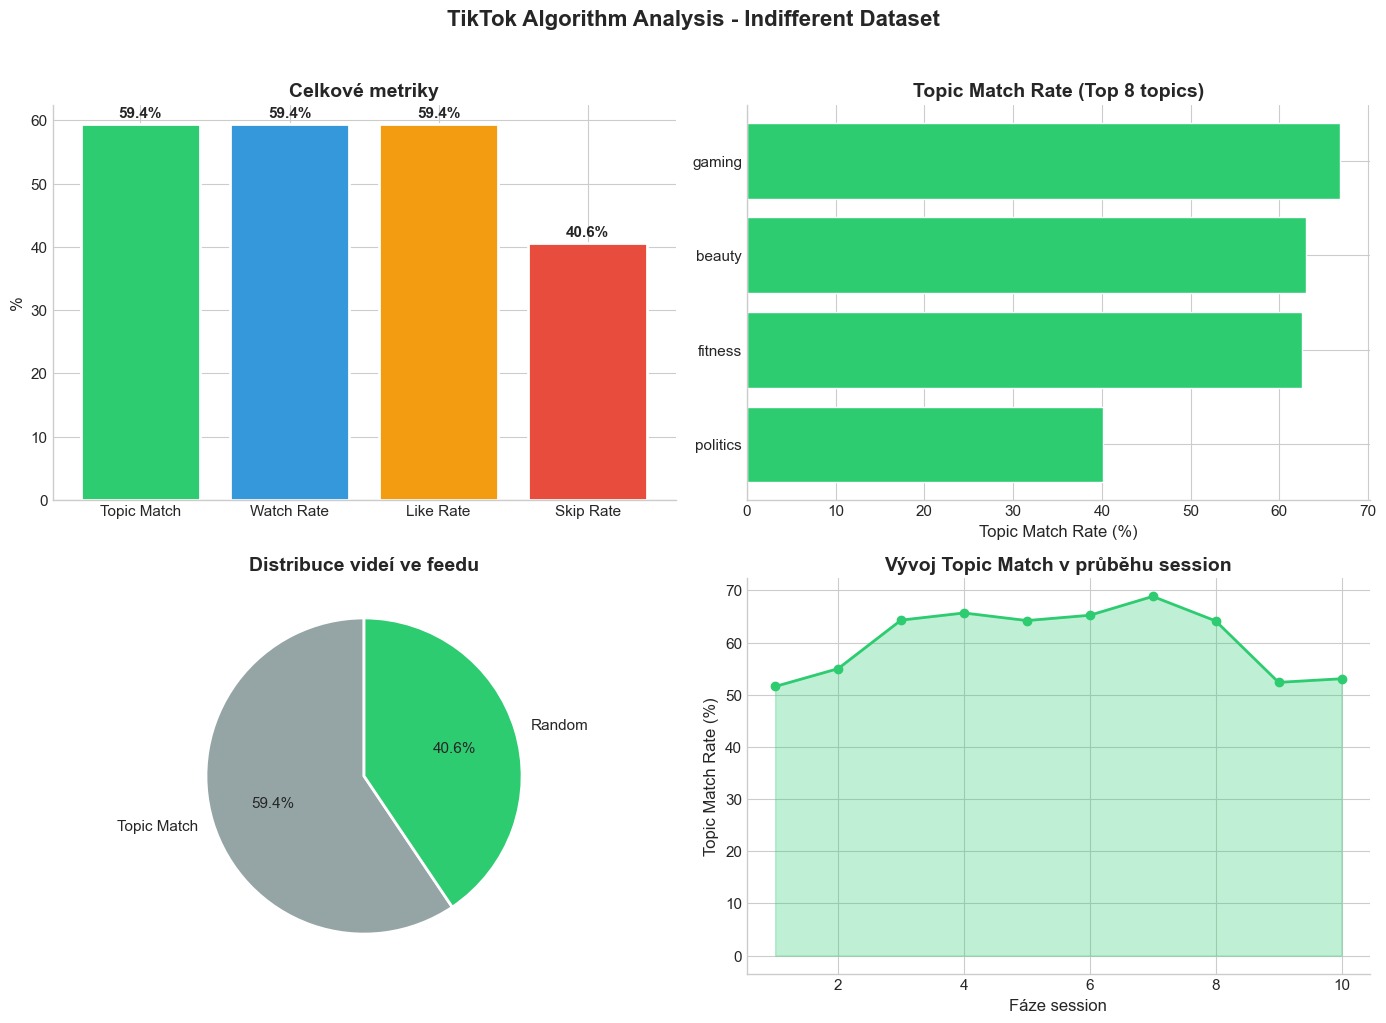


✓ VŠECHNY GRAFY ULOŽENY DO SLOŽKY 'output/'


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Celkové metriky
metrics = {
    'Topic Match': df['predicted_topic_match'].mean() * 100,
    'Watch Rate': df['video_action_watch'].mean() * 100,
    'Like Rate': df['video_action_like'].mean() * 100,
    'Skip Rate': df['video_action_skip'].mean() * 100
}
bars = axes[0,0].bar(metrics.keys(), metrics.values(), 
                     color=[COLORS['topic_match'], COLORS['watch'], COLORS['like'], COLORS['skip']],
                     edgecolor='white', linewidth=2)
for bar, val in zip(bars, metrics.values()):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0,0].set_ylabel('%')
axes[0,0].set_title('Celkové metriky', fontweight='bold')

# 2. Topic match rate podle topic (top 8)
topic_rates = df.groupby('topic')['predicted_topic_match'].mean().sort_values(ascending=True).tail(8) * 100
axes[0,1].barh(topic_rates.index, topic_rates.values, color=COLORS['topic_match'], edgecolor='white')
axes[0,1].set_xlabel('Topic Match Rate (%)')
axes[0,1].set_title('Topic Match Rate (Top 8 topics)', fontweight='bold')

# 3. Distribuce videí
cat_counts = df['video_category'].value_counts()
axes[1,0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
              colors=[COLORS['random'], COLORS['topic_match']], startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1,0].set_title('Distribuce videí ve feedu', fontweight='bold')

# 4. Vývoj v session
progress = df.groupby('interaction_bin')['predicted_topic_match'].mean() * 100
axes[1,1].plot(progress.index, progress.values, marker='o', linewidth=2, color=COLORS['topic_match'])
axes[1,1].fill_between(progress.index, progress.values, alpha=0.3, color=COLORS['topic_match'])
axes[1,1].set_xlabel('Fáze session')
axes[1,1].set_ylabel('Topic Match Rate (%)')
axes[1,1].set_title('Vývoj Topic Match v průběhu session', fontweight='bold')

plt.suptitle('TikTok Algorithm Analysis - Indifferent Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/11_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*80)
print("✓ VŠECHNY GRAFY ULOŽENY DO SLOŽKY 'output/'")
print("="*80)